In [78]:
!pwd

/gpfsm/dnb34/jli30/QEFM/qefm-core/notebooks


In [40]:
import matplotlib.pyplot as plt

In [41]:
import xarray as xr
import numpy as np
import pandas as pd

In [74]:
init_time = [np.datetime64("2024-09-26T12:00:00")]
ts_str = pd.to_datetime(init_time[0]).strftime("%Y%m%d_%H%M%S")
goes_variables =  ['abi01c', 'abi02c', 'abi03c', 'abi07c', 'abi08c', 'abi09c', 'abi10c', 'abi13c']
goes_channel = "abi13c"
mrms_channel = "refc"
goes_ch_idx = goes_variables.index(goes_channel)
mrms_ch_idx = 0 # mrms prediction single variable "refc"

In [44]:
file = f"/discover/nobackup/projects/imvi-nse/jli30/sc_gpu/Helene/stormscope_goes_forecast_{ts_str}.nc"
ds_goes = xr.open_dataset(file)
file = f"/discover/nobackup/projects/imvi-nse/jli30/sc_gpu/Helene/stormscope_mrms_forecast_{ts_str}.nc"
ds_mrms = xr.open_dataset(file)

In [50]:
ds_mrms

<xarray.Dataset> Size: 11MB
Dimensions:          (batch: 1, time: 1, lead_time: 6, variable: 1, y: 512,
                      x: 896)
Coordinates:
  * batch            (batch) int64 8B 0
  * time             (time) datetime64[ns] 8B 2024-09-26T12:00:00
  * lead_time        (lead_time) timedelta64[ns] 48B 01:00:00 ... 06:00:00
  * variable         (variable) <U4 16B 'refc'
  * y                (y) float64 4kB -1.536e+06 -1.53e+06 ... 1.524e+06 1.53e+06
  * x                (x) float64 7kB -2.689e+06 -2.683e+06 ... 2.681e+06
Data variables:
    stormscope_mrms  (batch, time, lead_time, variable, y, x) float32 11MB ...

In [54]:
field_goes = ds_goes["stormscope_goes"].isel(batch=0, time=0, lead_time=1, variable=goes_ch_idx)
field_mrms = ds_mrms["stormscope_mrms"].isel(batch=0, time=0, lead_time=1, variable=0)

numpy.timedelta64(7200000000000,'ns')

In [68]:
lead_time.astype('timedelta64[m]')

numpy.timedelta64(120,'m')

Text(0.5, 1.0, 'Predicted GOES abi13c \n from 20240926_120000 UTC initialization (lead 2:00:00)')

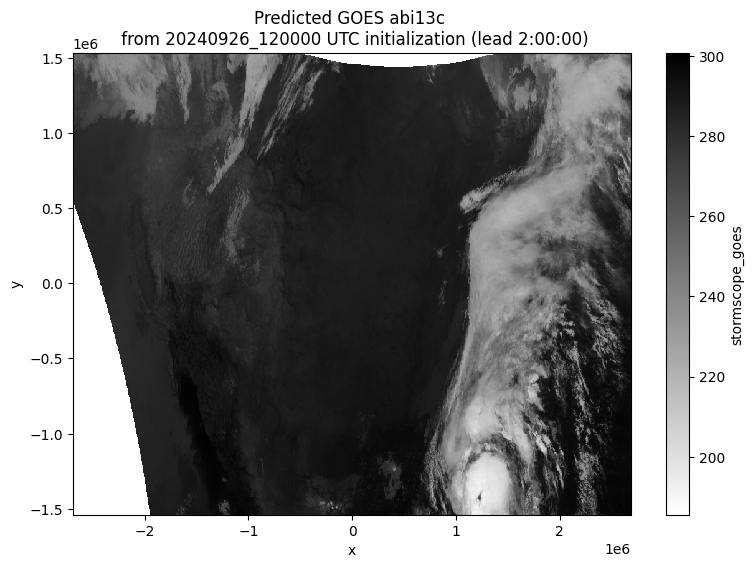

In [77]:
plt.figure(figsize=(9, 6))
field_goes.plot(cmap='gray_r')
lead_time = field_goes.lead_time.values
plt.title(
    f"Predicted GOES {goes_channel} \n from {ts_str} UTC "
    f"initialization (lead {lead_time.astype('timedelta64[h]').item()})"
)

Text(0.5, 1.0, 'Predicted MRMS refc \n from 20240926_120000 UTC initialization (lead 2:00:00)')

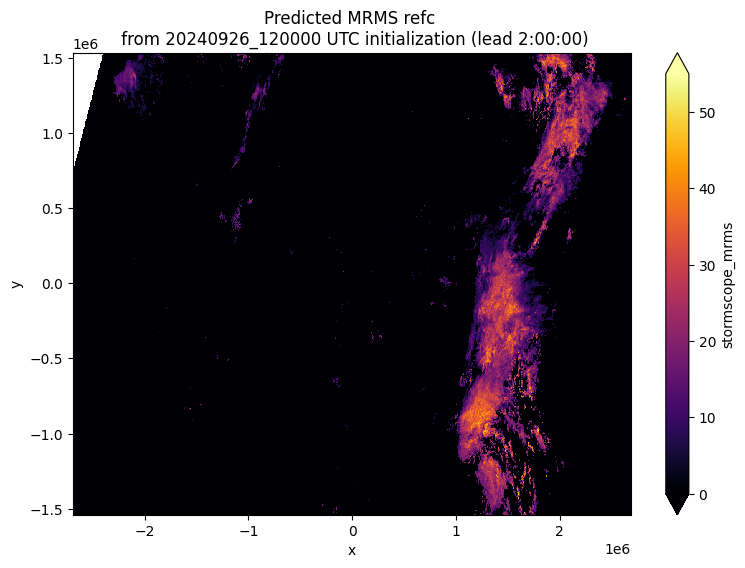

In [76]:
plt.figure(figsize=(9, 6))
field_mrms.plot(cmap='inferno', vmin=0.0, vmax=55.0)
lead_time = field_mrms.lead_time.values
plt.title(
    f"Predicted MRMS {mrms_channel} \n from {ts_str} UTC "
    f"initialization (lead {lead_time.astype('timedelta64[h]').item()})"
)